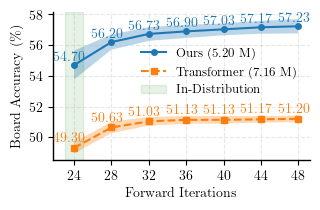

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

l = 5
index = np.arange(24, 49 + 1, 4)
ours = np.array(
    [
        [54.8, 56.6, 57.0, 57.1, 57.2, 57.3, 57.4],
        [53.5, 55.5, 56.1, 56.3, 56.5, 56.6, 56.6],
        [55.8, 56.5, 57.1, 57.3, 57.4, 57.6, 57.7],
    ]
)
tf = np.array(
    [
        [49.1, 50.2, 50.7, 50.8, 50.8, 50.9, 50.9],
        [49.8, 51.1, 51.4, 51.4, 51.4, 51.4, 51.4],
        [49.0, 50.6, 51.0, 51.2, 51.2, 51.2, 51.3],
    ]
)
ours_mean = np.mean(ours, axis=0)
ours_std = np.std(ours, axis=0)
tf_mean = np.mean(tf, axis=0)
tf_std = np.std(tf, axis=0)

plt.rcParams.update(
    {
        "text.usetex": True,
        "font.size": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "font.family": "Times New Roman",
        "grid.alpha": 0.3,
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
    }
)
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # (3.3, 2.5)

ax.set_xticks(index)
ax.set_xlabel("Forward Iterations")
ax.set_ylabel(r"Board Accuracy (\%)")

ax.plot(index, ours_mean, "o-", label="Ours (5.20 M)", markersize=4)
for x, y in zip(index, ours_mean):
    ax.text(x - 2.2, y + 0.3, f"{y:.2f}", color="C0")

ax.fill_between(index, ours_mean - ours_std, ours_mean + ours_std, alpha=0.3)
ax.plot(index, tf_mean, "s--", label="Transformer (7.16 M)", markersize=4)
for x, y in zip(index, tf_mean):
    ax.text(x - 2.2, y + 0.4, f"{y:.2f}", color="C1")
# plt.plot(index[0], tf_mean[0], "D", label="Transformer (In-Distribution)", color="C1")
ax.fill_between(index, tf_mean - tf_std, tf_mean + tf_std, alpha=0.3)
ax.axvspan(23, 25, color="green", alpha=0.1, label="In-Distribution")
# plt.axvspan(26, 50, color='gray', alpha=0.1, label="Out-of-Distribution")
# Remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True)
ax.legend(frameon=False, loc="best", bbox_to_anchor=(0.3, 0.06, 0.5, 0.78))
plt.tight_layout()
# plt.savefig("sudoku_extropolation.pdf", bbox_inches="tight", dpi=600)
plt.show()